In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
import sys

sys.path.insert(0, str(Path("..").resolve()))

from src.transform.features import build_features
from src.ml.anomaly import load_anomaly_model, detect, ANOMALY_FEATURE_COLS

%matplotlib inline
plt.rcParams["figure.figsize"] = (14, 5)

In [3]:
df_raw  = pd.read_csv("../data/processed/historical_data.csv", parse_dates=["timestamp"])
df_feat = build_features(df_raw)

print(f"Shape: {df_feat.shape}")
print(f"Date range: {df_feat['timestamp'].min()} → {df_feat['timestamp'].max()}")
df_feat[ANOMALY_FEATURE_COLS].describe()

Shape: (7968, 25)
Date range: 2026-01-08 00:00:00 → 2026-06-22 23:00:00


,hour,month,city_encoded,temperature_2m_c,relative_humidity_pct,wind_speed_10m_kmh,pm2_5_lag_1h,pm2_5_lag_24h,pm2_5_lag_168h,pm2_5_roll_mean_24h,pm2_5_roll_std_24h,pm2_5_ugm3
count,7968.000000,7968.000000,7968.000000,7968.000000,7968.000000,7968.000000,7968.000000,7968.000000,7968.000000,7968.000000,7968.000000,7968.000000
mean,11.500000,3.493976,0.500000,27.758220,77.418800,7.541466,49.771624,49.897892,50.149260,49.809271,20.424954,49.758823
std,6.922621,1.619811,0.500031,2.524568,13.180746,4.085646,32.520048,32.505531,32.359188,23.063308,11.337446,32.510111
min,0.000000,1.000000,0.000000,22.500000,33.000000,0.000000,5.200000,5.200000,5.200000,10.700000,1.494040,5.200000
25%,5.750000,2.000000,0.000000,25.700000,69.000000,4.400000,25.300000,25.400000,25.700000,30.551042,11.074446,25.300000
50%,11.500000,3.500000,0.500000,27.500000,80.000000,6.900000,39.250000,39.500000,39.800000,44.379167,18.835727,39.200000
75%,17.250000,5.000000,1.000000,29.600000,88.000000,10.300000,66.800000,66.800000,67.500000,66.742708,28.748737,66.650000
max,23.000000,6.000000,1.000000,36.000000,100.000000,25.500000,207.700000,207.700000,207.700000,119.795833,55.872100,207.700000


In [4]:
model  = load_anomaly_model(Path("../models/isolation_forest.pkl"))
result = detect(model, df_feat)

n_anomalies = result["is_anomaly"].sum()
print(f"Total anomalies: {n_anomalies} / {len(result)} ({n_anomalies/len(result)*100:.1f}%)")
print()
print(result.groupby("city")["is_anomaly"].sum().rename("anomalies flagged"))

Total anomalies: 399 / 7968 (5.0%)

city
jakarta     350
surabaya     49
Name: anomalies flagged, dtype: int64


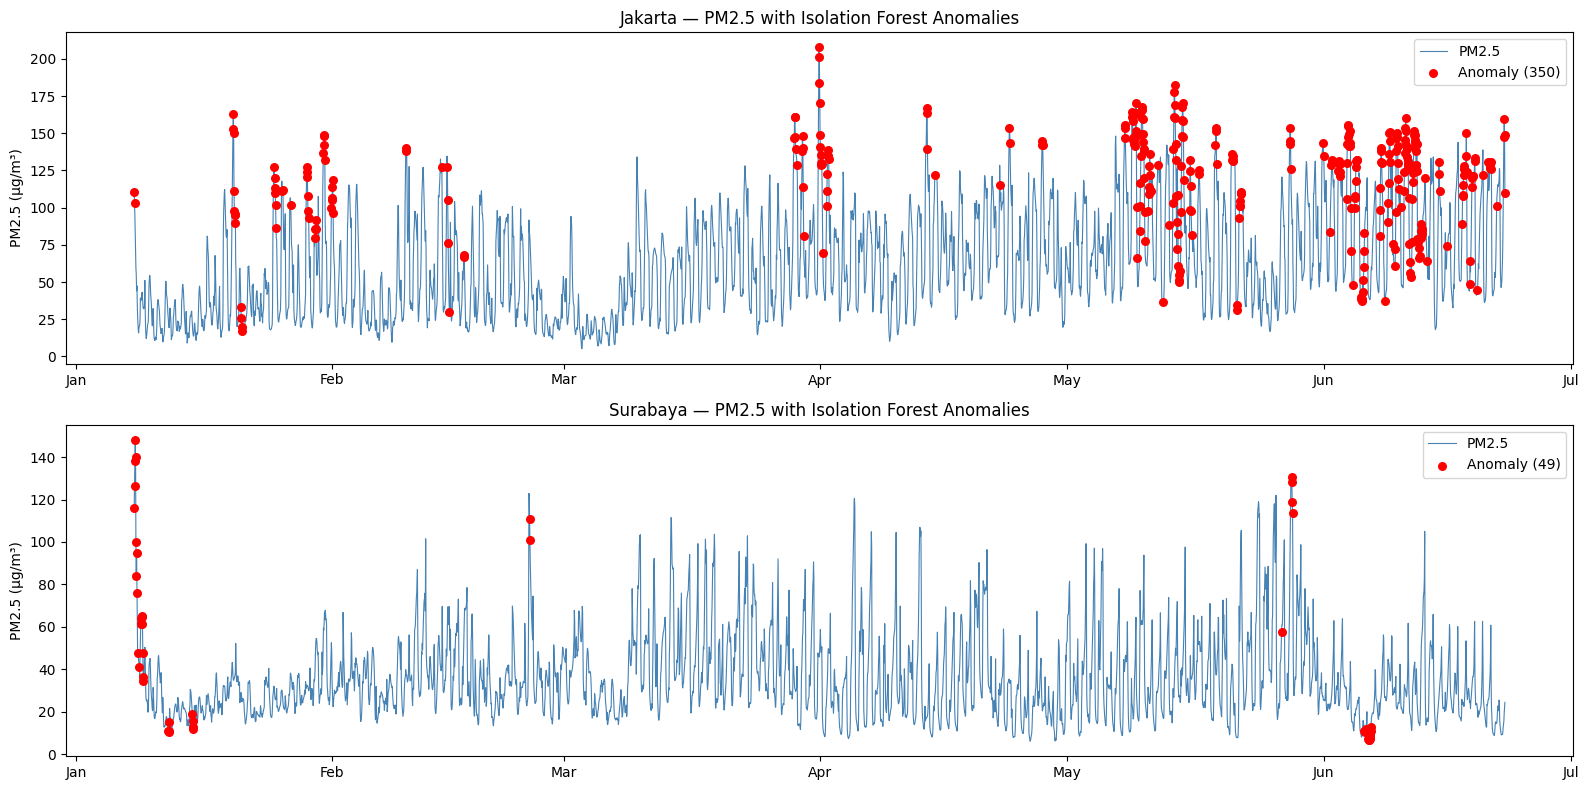

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

for ax, city in zip(axes, ["jakarta", "surabaya"]):
    city_df  = result[result["city"] == city].sort_values("timestamp")
    normal   = city_df[~city_df["is_anomaly"]]
    anomaly  = city_df[city_df["is_anomaly"]]

    ax.plot(city_df["timestamp"], city_df["pm2_5_ugm3"],
            color="steelblue", linewidth=0.8, label="PM2.5")
    ax.scatter(anomaly["timestamp"], anomaly["pm2_5_ugm3"],
               color="red", s=30, zorder=5, label=f"Anomaly ({len(anomaly)})")

    ax.set_title(f"{city.capitalize()} — PM2.5 with Isolation Forest Anomalies")
    ax.set_ylabel("PM2.5 (µg/m³)")
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

plt.tight_layout()
plt.show()

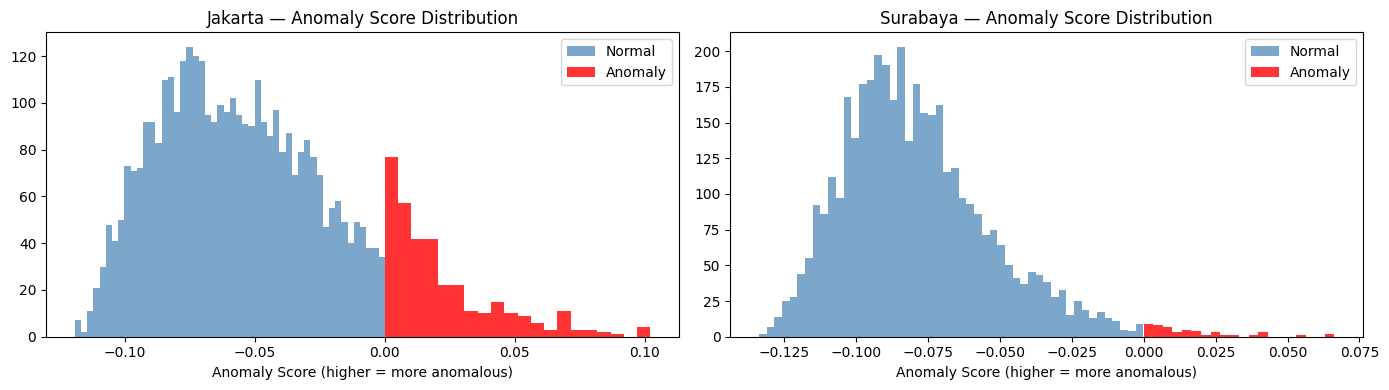

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, city in zip(axes, ["jakarta", "surabaya"]):
    city_df = result[result["city"] == city]
    ax.hist(city_df[~city_df["is_anomaly"]]["anomaly_score"],
            bins=50, alpha=0.7, color="steelblue", label="Normal")
    ax.hist(city_df[city_df["is_anomaly"]]["anomaly_score"],
            bins=20, alpha=0.8, color="red", label="Anomaly")
    ax.set_title(f"{city.capitalize()} — Anomaly Score Distribution")
    ax.set_xlabel("Anomaly Score (higher = more anomalous)")
    ax.legend()

plt.tight_layout()
plt.show()

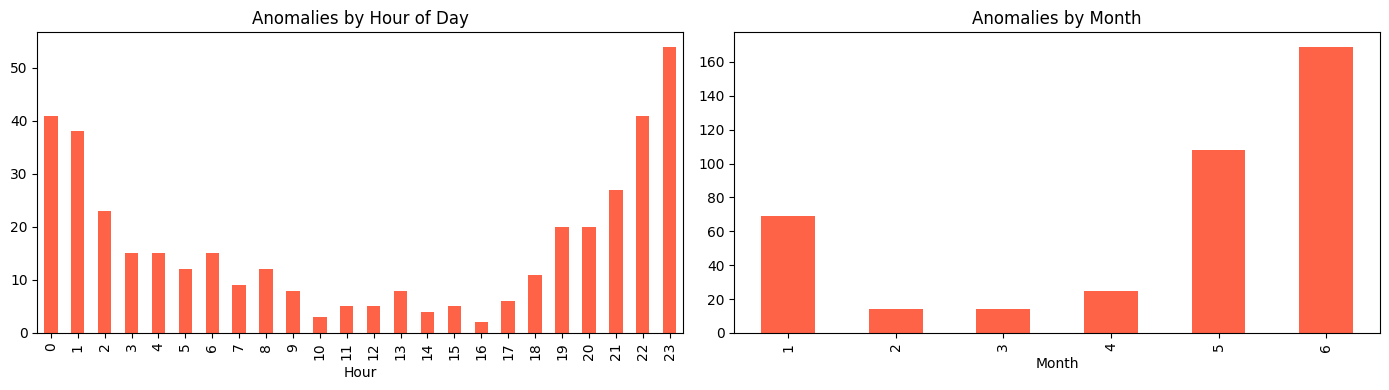

In [7]:
anom_only = result[result["is_anomaly"]].copy()
anom_only["hour"]  = anom_only["timestamp"].dt.hour
anom_only["month"] = anom_only["timestamp"].dt.month

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

anom_only.groupby("hour")["is_anomaly"].count().plot(
    kind="bar", ax=axes[0], color="tomato")
axes[0].set_title("Anomalies by Hour of Day")
axes[0].set_xlabel("Hour")

anom_only.groupby("month")["is_anomaly"].count().plot(
    kind="bar", ax=axes[1], color="tomato")
axes[1].set_title("Anomalies by Month")
axes[1].set_xlabel("Month")

plt.tight_layout()
plt.show()

In [8]:
top10 = result.nlargest(10, "anomaly_score")[
    ["timestamp", "city", "pm2_5_ugm3", "anomaly_score", "is_anomaly"]
].reset_index(drop=True)

print("Top 10 most anomalous readings:")
print(top10.to_string())

Top 10 most anomalous readings:
            timestamp     city  pm2_5_ugm3  anomaly_score  is_anomaly
0 2026-05-10 01:00:00  jakarta       165.3         0.1022        True
1 2026-05-10 02:00:00  jakarta       159.3         0.1014        True
2 2026-05-14 23:00:00  jakarta       170.4         0.1006        True
3 2026-05-14 22:00:00  jakarta       167.6         0.0973        True
4 2026-05-14 21:00:00  jakarta       158.8         0.0873        True
5 2026-06-09 22:00:00  jakarta       147.6         0.0823        True
6 2026-05-15 00:00:00  jakarta       158.3         0.0820        True
7 2026-06-09 23:00:00  jakarta       141.6         0.0808        True
8 2026-05-13 23:00:00  jakarta       182.1         0.0786        True
9 2026-06-10 23:00:00  jakarta       160.2         0.0782        True
